# Food Quality vs Urbanization
How does the urbanization of a city affect the quality of food served by restaurants on Foodpanda?


## Exploring the data

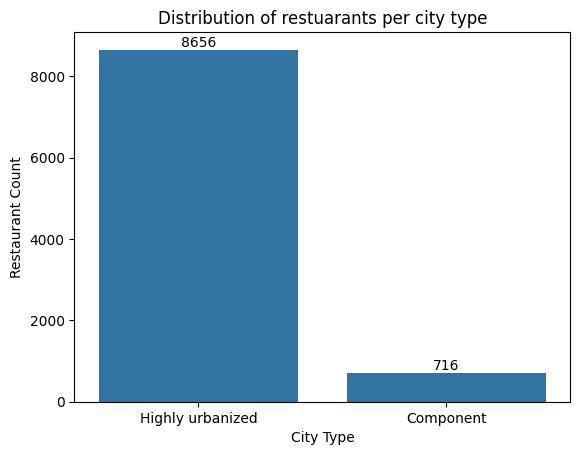

In [ ]:
from data_preprocessing import ph_restos
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cities = ph_restos["City"].unique();

highly_urbanized_cities = [
    'cebu city',
    'davao city davao del sur',
    'lapu-lapu city cebu',
    'makati city',
    'mandaluyong city',
    'manila',
    'marikina',
    'muntinlupa city',
    'pasay city',
    'pasig city',
    'quezon city',
    'san juan',
    'taguig city'
]

component_cities = [
    'dagupan pangasinan',
    'koronadal south cotabato',
    'malolos bulacan',
    'ormoc leyte',
    'valencia bukidnon'
]

def label_city(vector):
    if vector["City"] in highly_urbanized_cities:
        return "Highly urbanized" 
    else:
        return "Component"

ph_restos["CityType"] = ph_restos.apply(label_city, axis=1)
ph_restos.head()

ax = sns.countplot(data=ph_restos, x='CityType')
ax.bar_label(ax.containers[0]) # type: ignore

plt.xlabel("City Type")
plt.ylabel("Restaurant Count")
plt.title("Distribution of restuarants per city type")
plt.show()

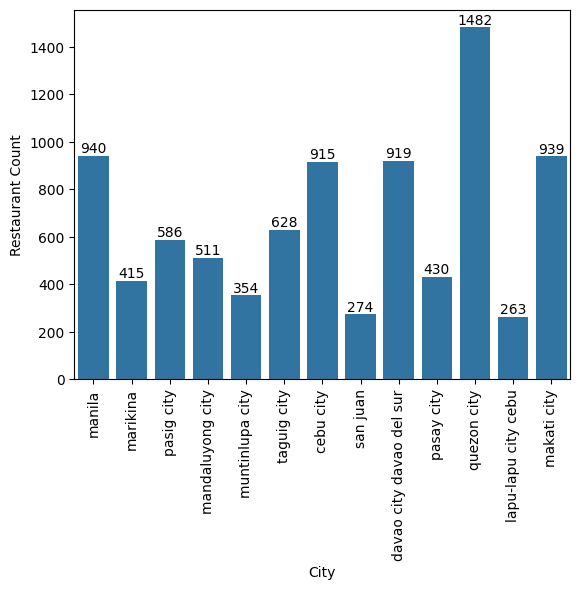

In [25]:
ax = sns.countplot(data=ph_restos[ph_restos["City"].isin(highly_urbanized_cities)], x = "City")
ax.tick_params(axis='x', rotation=90)
ax.bar_label(ax.containers[0]) # type: ignore
plt.xlabel("City")
plt.ylabel("Restaurant Count")
plt.show()

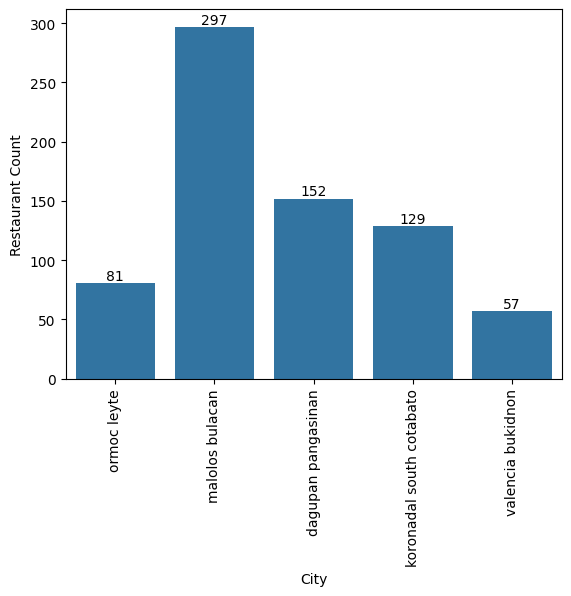

In [26]:
ax = sns.countplot(data=ph_restos[ph_restos["City"].isin(component_cities)], x = "City")
ax.tick_params(axis='x', rotation=90)
ax.bar_label(ax.containers[0]) # type: ignore
plt.xlabel("City")
plt.ylabel("Restaurant Count")
plt.show()

## Creating the Contingency Table for Chi Squared Test
Is the urbanization of a city independent of the rating of restaurants?

In [ ]:
urban_ratings_distribution = {}
